In [1]:
from matplotlib.lines import Line2D
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import textwrap
import yaml

from _configs.country_config import *
from _configs.files_config import *
from _configs.run_config import *

from _utils.utils import *

In [2]:
input_data = yaml.safe_load((Path(VALIDATION_RUN_INPUTS_DIR)/"input_validation.yml").read_text(encoding="utf-8"))
# input_data = yaml.safe_load((Path(VALIDATION_RUN_INPUTS_DIR)/"input_population_bins_beta_zero_pop_0.25.yml").read_text(encoding="utf-8"))

population_scale_from_input_yml = input_data["population_demographic"]["artificial_rescaling_of_population_size"]

In [3]:
analysis_path = Path(validation_path) / "analysis"

agg_clinical_episodes = pd.read_csv(f"{analysis_path}/agg_clinical_episodes.csv")
agg_clinical_episodes_2_to_10 = pd.read_csv(f"{analysis_path}/agg_clinical_episodes_2_to_10.csv")
agg_clinical_episodes_under_5 = pd.read_csv(f"{analysis_path}/agg_clinical_episodes_under_5.csv")
agg_prevalence_2_to_10 = pd.read_csv(f"{analysis_path}/agg_prevalence_2_to_10.csv")
agg_prevalence_under_5 = pd.read_csv(f"{analysis_path}/agg_prevalence_under_5.csv")
agg_population = pd.read_csv(f"{analysis_path}/agg_population.csv")
agg_treatment = pd.read_csv(f"{analysis_path}/agg_treatment.csv")

In [4]:
drop_columns=["monthly_data_id","unit_id"]
# multiply all other columns by population_scale_from_input_yml to get the actual population
for col in agg_population.columns:
    if col not in drop_columns:
        agg_population[col] /= population_scale_from_input_yml

In [5]:
agg_population["mean_population"] = agg_population.drop(columns=["monthly_data_id","unit_id"]).mean(axis=1).astype(int)
agg_population

,monthly_data_id,unit_id,population_0,population_1,population_2,population_3,population_4,population_5,population_6,population_7,...,population_11,population_12,population_13,population_14,population_15,population_16,population_17,population_18,population_19,mean_population
0,1,1,5553664.0,5553620.0,5553672.0,5553656.0,5553584.0,5553620.0,5553588.0,5553636.0,...,5553524.0,5553684.0,5553632.0,5553636.0,5553684.0,5553608.0,5553720.0,5553496.0,5553568.0,5553620
1,1,2,3443472.0,3443568.0,3443504.0,3443492.0,3443620.0,3443540.0,3443560.0,3443524.0,...,3443548.0,3443604.0,3443588.0,3443500.0,3443576.0,3443576.0,3443624.0,3443504.0,3443600.0,3443556
2,1,3,2822320.0,2822328.0,2822280.0,2822296.0,2822304.0,2822316.0,2822212.0,2822284.0,...,2822264.0,2822344.0,2822332.0,2822284.0,2822212.0,2822340.0,2822336.0,2822356.0,2822320.0,2822306
3,1,4,2388808.0,2388864.0,2388792.0,2388776.0,2388864.0,2388860.0,2388844.0,2388804.0,...,2388816.0,2388788.0,2388876.0,2388804.0,2388820.0,2388884.0,2388816.0,2388848.0,2388820.0,2388826
4,1,5,4088060.0,4088116.0,4088084.0,4088048.0,4088104.0,4088076.0,4088116.0,4088092.0,...,4088232.0,4088016.0,4088100.0,4088028.0,4088072.0,4088112.0,4088120.0,4087996.0,4088168.0,4088094
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
937,157,2,4178012.0,4183628.0,4179824.0,4185468.0,4180452.0,4185276.0,4179504.0,4182544.0,...,4184448.0,4177844.0,4182660.0,4181128.0,4179128.0,4181192.0,4180468.0,4179764.0,4183228.0,4181261
938,157,3,3528844.0,3529020.0,3535320.0,3532604.0,3533480.0,3527220.0,3535872.0,3532800.0,...,3532516.0,3530820.0,3536312.0,3535436.0,3527716.0,3537580.0,3538168.0,3532684.0,3538032.0,3533033
939,157,4,2915872.0,2911884.0,2916312.0,2920072.0,2916864.0,2913696.0,2914648.0,2921164.0,...,2916072.0,2917496.0,2915524.0,2914080.0,2915016.0,2918244.0,2918500.0,2920440.0,2914100.0,2916517
940,157,5,5080820.0,5078964.0,5081720.0,5075768.0,5079116.0,5075704.0,5082520.0,5076884.0,...,5077372.0,5081152.0,5079624.0,5083224.0,5073824.0,5080240.0,5079508.0,5081156.0,5072520.0,5078644


In [6]:
# get total population for each month
population_cols = [col for col in agg_population.columns if col.startswith('population_') or col == 'mean_population']
print(f"Population columns: {population_cols}")
total_population = agg_population.groupby('monthly_data_id')[population_cols].sum(min_count=1).reset_index()
# drop cols with nan values
total_population = total_population.dropna(axis=1, how='any')
total_population.set_index('monthly_data_id')
total_population.to_csv(f"{analysis_path}/total_population_by_month.csv", index=False)
total_population

Population columns: ['population_0', 'population_1', 'population_2', 'population_3', 'population_4', 'population_5', 'population_6', 'population_7', 'population_8', 'population_9', 'population_10', 'population_11', 'population_12', 'population_13', 'population_14', 'population_15', 'population_16', 'population_17', 'population_18', 'population_19', 'mean_population']


,monthly_data_id,population_0,population_1,population_2,population_3,population_4,population_5,population_6,population_7,population_8,...,population_11,population_12,population_13,population_14,population_15,population_16,population_17,population_18,population_19,mean_population
0,1,21105808.0,21106056.0,21105856.0,21105752.0,21106000.0,21105924.0,21105856.0,21105872.0,21105980.0,...,21105872.0,21105924.0,21106004.0,21105748.0,21105848.0,21106056.0,21106092.0,21105636.0,21105920.0,21105898
1,2,21126072.0,21125884.0,21126184.0,21125344.0,21126592.0,21125276.0,21126264.0,21126404.0,21126364.0,...,21126516.0,21125632.0,21125968.0,21126420.0,21125840.0,21126260.0,21125736.0,21125304.0,21126480.0,21126061
2,3,21120320.0,21118940.0,21120304.0,21119956.0,21119948.0,21119436.0,21119476.0,21120028.0,21119904.0,...,21120072.0,21119524.0,21118612.0,21120484.0,21118756.0,21120324.0,21119452.0,21119008.0,21119904.0,21119727
3,4,21111544.0,21108852.0,21111792.0,21110104.0,21110352.0,21111748.0,21111276.0,21110724.0,21110372.0,...,21110604.0,21109056.0,21109336.0,21109596.0,21108996.0,21110372.0,21110112.0,21110540.0,21109856.0,21110318
4,5,21107140.0,21105444.0,21107388.0,21105280.0,21107012.0,21108196.0,21107452.0,21107300.0,21106644.0,...,21107340.0,21106180.0,21104148.0,21105880.0,21107044.0,21106484.0,21106748.0,21106904.0,21105688.0,21106560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,153,25944648.0,25941728.0,25960524.0,25945552.0,25941448.0,25945976.0,25948136.0,25944112.0,25945048.0,...,25944808.0,25948080.0,25947840.0,25949068.0,25927148.0,25956504.0,25953596.0,25951388.0,25945000.0,25946247
153,154,25979848.0,25975632.0,25995168.0,25980900.0,25975796.0,25979988.0,25982180.0,25978364.0,25979876.0,...,25980580.0,25983496.0,25983284.0,25983760.0,25961956.0,25991356.0,25987392.0,25986232.0,25979868.0,25981004
154,155,26016272.0,26010912.0,26030444.0,26017732.0,26011968.0,26015808.0,26018520.0,26014228.0,26016188.0,...,26015616.0,26019776.0,26020540.0,26020736.0,25998100.0,26027604.0,26024160.0,26023592.0,26016580.0,26017300
155,156,26052180.0,26045992.0,26064476.0,26053156.0,26047624.0,26050068.0,26055560.0,26049188.0,26051004.0,...,26051968.0,26055792.0,26056708.0,26056632.0,26033576.0,26063160.0,26060732.0,26059432.0,26052408.0,26052812


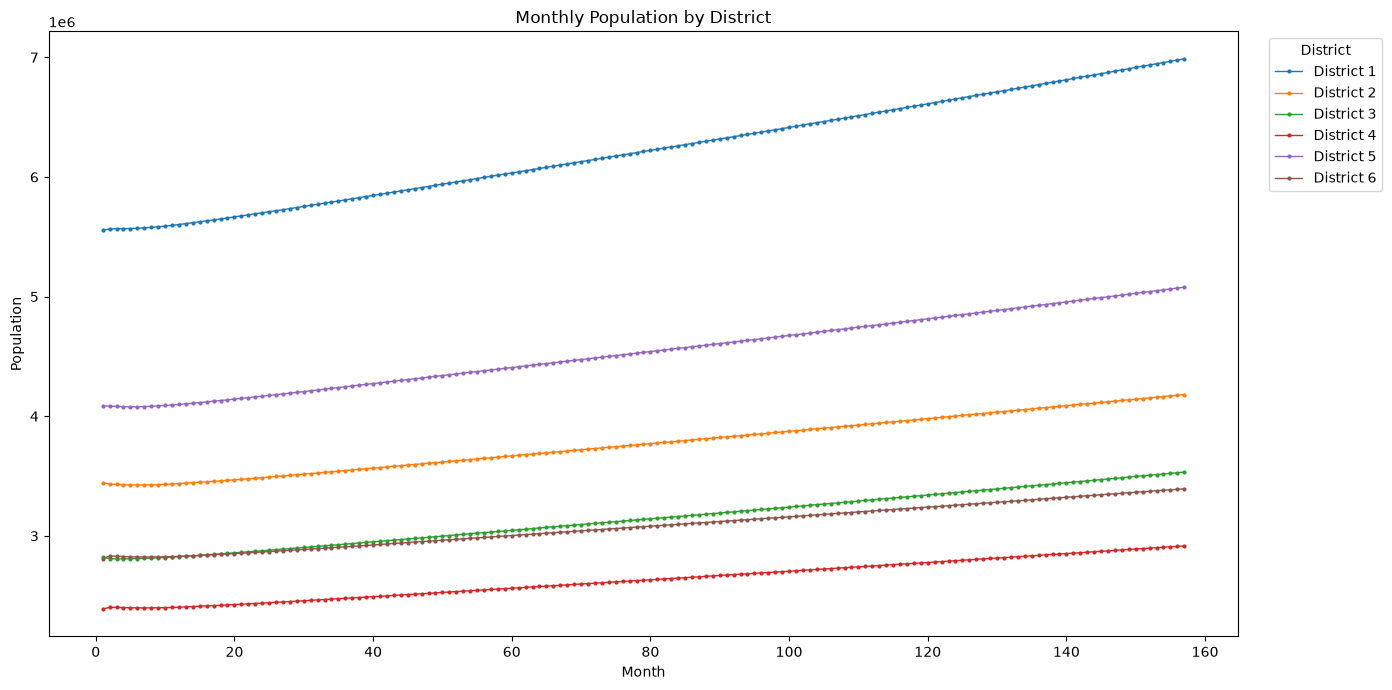

In [7]:
fig, ax = plt.subplots(figsize=(14, 7))

# Plot one line per district (unit_id), using mean_population as the value
for unit_id, group in agg_population.groupby('unit_id'):
    group_sorted = group.sort_values('monthly_data_id')
    ax.plot(
        group_sorted['monthly_data_id'],
        group_sorted['mean_population'],
        label=f'District {unit_id}',
        marker='o',
        markersize=2,
        linewidth=1
    )

ax.set_xlabel('Month')
ax.set_ylabel('Population')
ax.set_title('Monthly Population by District')
ax.legend(title='District', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

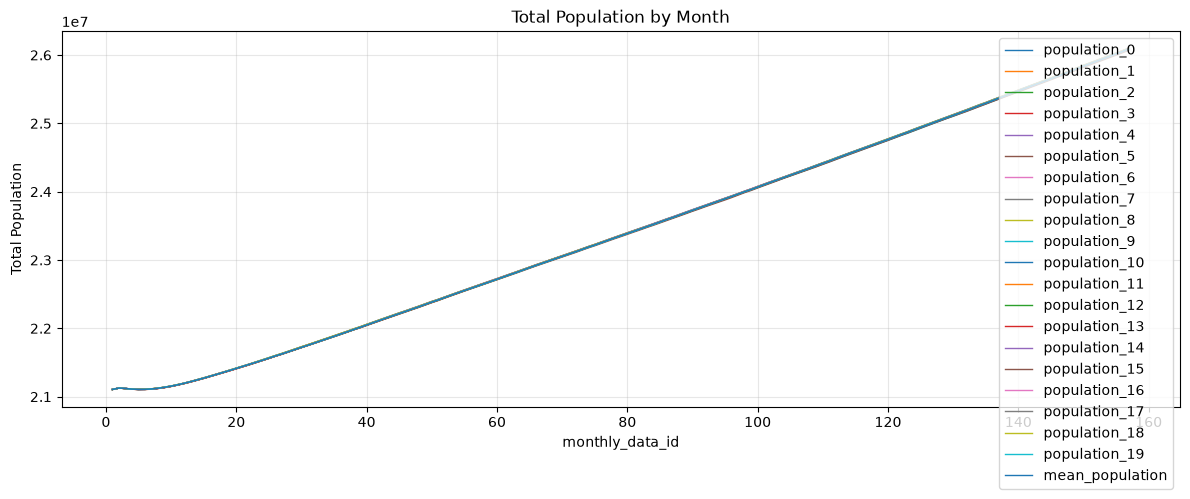

In [8]:
cols = [c for c in total_population.columns if c != 'monthly_data_id']
total_population.plot(
    x='monthly_data_id',
    y=cols,
    figsize=(12, 5),
    legend=True,
    linewidth=1,
    marker=None
)
plt.title("Total Population by Month")
plt.xlabel("monthly_data_id")
plt.ylabel("Total Population")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
total_population

,monthly_data_id,population_0,population_1,population_2,population_3,population_4,population_5,population_6,population_7,population_8,...,population_11,population_12,population_13,population_14,population_15,population_16,population_17,population_18,population_19,mean_population
0,1,21105808.0,21106056.0,21105856.0,21105752.0,21106000.0,21105924.0,21105856.0,21105872.0,21105980.0,...,21105872.0,21105924.0,21106004.0,21105748.0,21105848.0,21106056.0,21106092.0,21105636.0,21105920.0,21105898
1,2,21126072.0,21125884.0,21126184.0,21125344.0,21126592.0,21125276.0,21126264.0,21126404.0,21126364.0,...,21126516.0,21125632.0,21125968.0,21126420.0,21125840.0,21126260.0,21125736.0,21125304.0,21126480.0,21126061
2,3,21120320.0,21118940.0,21120304.0,21119956.0,21119948.0,21119436.0,21119476.0,21120028.0,21119904.0,...,21120072.0,21119524.0,21118612.0,21120484.0,21118756.0,21120324.0,21119452.0,21119008.0,21119904.0,21119727
3,4,21111544.0,21108852.0,21111792.0,21110104.0,21110352.0,21111748.0,21111276.0,21110724.0,21110372.0,...,21110604.0,21109056.0,21109336.0,21109596.0,21108996.0,21110372.0,21110112.0,21110540.0,21109856.0,21110318
4,5,21107140.0,21105444.0,21107388.0,21105280.0,21107012.0,21108196.0,21107452.0,21107300.0,21106644.0,...,21107340.0,21106180.0,21104148.0,21105880.0,21107044.0,21106484.0,21106748.0,21106904.0,21105688.0,21106560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,153,25944648.0,25941728.0,25960524.0,25945552.0,25941448.0,25945976.0,25948136.0,25944112.0,25945048.0,...,25944808.0,25948080.0,25947840.0,25949068.0,25927148.0,25956504.0,25953596.0,25951388.0,25945000.0,25946247
153,154,25979848.0,25975632.0,25995168.0,25980900.0,25975796.0,25979988.0,25982180.0,25978364.0,25979876.0,...,25980580.0,25983496.0,25983284.0,25983760.0,25961956.0,25991356.0,25987392.0,25986232.0,25979868.0,25981004
154,155,26016272.0,26010912.0,26030444.0,26017732.0,26011968.0,26015808.0,26018520.0,26014228.0,26016188.0,...,26015616.0,26019776.0,26020540.0,26020736.0,25998100.0,26027604.0,26024160.0,26023592.0,26016580.0,26017300
155,156,26052180.0,26045992.0,26064476.0,26053156.0,26047624.0,26050068.0,26055560.0,26049188.0,26051004.0,...,26051968.0,26055792.0,26056708.0,26056632.0,26033576.0,26063160.0,26060732.0,26059432.0,26052408.0,26052812


## Compare simulated population to observed population raster in that year. Our Population raster is in 2020 so we will use that year.

In [10]:
observed_population_raster, metadata = read_raster(observed_population_raster_path)
nodata = metadata["NODATA_value"]
total_observed_population_observed_year = np.sum(observed_population_raster[observed_population_raster != nodata])

print(f"Total population observed in raster ({observed_population_year}): {total_observed_population_observed_year:,.0f}")

Total population observed in raster (2020): 24,572,163


In [11]:
year_offset = observed_population_year - initial_year
start_idx = year_offset * 12
end_idx = start_idx + 12

total_final_population_from_sim = int(
    total_population["mean_population"].iloc[start_idx:end_idx].mean()
)

print(
    f"Total simulated population ({observed_population_year}): {total_final_population_from_sim:,.0f}"
)

Total simulated population (2020): 24,572,134


In [12]:
# percent diff
pop_pct_diff = (total_final_population_from_sim - total_observed_population_observed_year) / ((total_final_population_from_sim + total_observed_population_observed_year) / 2) * 100

print(f"Percent difference: {pop_pct_diff:.2f}%")

Percent difference: -0.00%


<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:57: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:57: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2253772/1463304329.py:3: SyntaxWarning: invalid escape sequence '\d'
  ax.set_title(f"{observed_population_year} Population Observed vs Simulated$^\dagger$", pad=20)
/tmp/ipykernel_2253772/1463304329.py:57: SyntaxWarning: invalid escape sequence '\d'
  fig.text(0.5, 0.02, f"$\dagger$ Mean {validation_replicates} replicates",
/tmp/ipykernel_2253772/1463304329.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([textwrap.fill(label.get_text(), wrap_width) for label in ax.get_xticklabels()])
findfont: Failed to find font weight 600, now using 700.


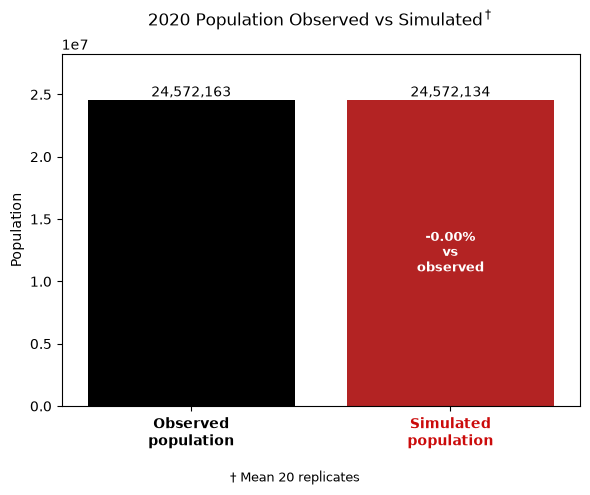

In [13]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.set_title(f"{observed_population_year} Population Observed vs Simulated$^\dagger$", pad=20)
ax.set_ylabel("Population")

cases_palette = {
    "Observed":               "#000000",  # black, outside the family entirely
    "Simulated (Total)":      "#CB0B0B",  # hsl(0, 90%, 42%) — vivid anchor
    "Simulated (Treated)":    "#962C2C",
    "Simulated (Untreated)":  "#D36969",
    "Simulated (Public)":     "#6E3535",
    "Simulated (Private)":    "#B96E6E",
}

labels = ["Observed population", "Simulated population"]
values = [total_observed_population_observed_year, total_final_population_from_sim]

plot_pop = sns.barplot(
    x=labels,
    y=values,
    hue=["Observed", "Simulated (Total)"],
    palette=cases_palette,
    legend=False,
    ax=ax
)

# Annotate each bar with its value
for bar, val in zip(ax.patches, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f'{val:,.0f}', ha='center', va='bottom', fontsize=10)

# Annotate percentage difference on the simulated bar specifically
sim_bar = ax.patches[1]
ax.text(sim_bar.get_x() + sim_bar.get_width() / 2, sim_bar.get_height() * 0.5,
         f'{pop_pct_diff:+.2f}%\nvs\nobserved', ha='center', va='center',
         fontsize=9, color='white', fontweight=600)

# Wrap and color-code x tick labels
wrap_width = 12
ax.set_xticklabels([textwrap.fill(label.get_text(), wrap_width) for label in ax.get_xticklabels()])

label_colors = {
    "Observed population": cases_palette["Observed"],
    "Simulated population": cases_palette["Simulated (Total)"],
}

for label in ax.get_xticklabels():
    label_text = label.get_text().replace("\n", " ")
    if label_text in label_colors:
        label.set_color(label_colors[label_text])
        label.set_fontweight('bold')

ax.margins(y=0.15)
ax.tick_params(axis='x', labelrotation=0)

plt.tight_layout(rect=[0, 0.06, 1, 1])
fig.text(0.5, 0.02, f"$\dagger$ Mean {validation_replicates} replicates",
          ha='center', va='bottom', fontsize=9)

plt.savefig(f"{analysis_path}/{observed_population_year}_observed_vs_simulated_population.png", dpi=200)
plt.show()